# IC50 MPro QED Novel: Token Usage and Cost Analysis

This notebook reconstructs what was actually sent to the LLM for each optimization iteration, estimates prompt token usage across information modes, and estimates run costs including the final summary-node call.

## Scope

- Modes: Full XAI, Partial XAI, No XAI, No Description
- Repetitions: 3 runs per mode
- Main plots:
  - Current prompt input tokens per iteration (mean over repetitions)
  - Cumulative prompt input tokens up to each iteration (mean over repetitions)
- Additional outputs:
  - Mean appended feedback size and prompt growth delta
  - Context-window projections (200k)
  - Cost estimates for 50 optimization iterations + final summary call

## Important notes

- Prompt-side token counts use Anthropic `messages/count_tokens` when `ANTHROPIC_API_KEY` is set.
- Anthropic documents these counts as estimates (typically close), not guaranteed exact billing numbers.
- Completion-side values are estimated from saved text because per-call output token metadata was not persisted in the original run logs.

In [14]:
import hashlib
import json
import os
import re
from dataclasses import dataclass
from pathlib import Path
from typing import Any

from anthropic import Anthropic
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Reproducibility
np.random.seed(42)

plt.rcParams.update(
    {
        "font.size": 12,
        "font.family": "serif",
        "axes.labelsize": 13,
        "axes.titlesize": 14,
        "xtick.labelsize": 11,
        "ytick.labelsize": 11,
        "legend.fontsize": 11,
        "figure.figsize": (7, 4),
        "axes.linewidth": 1.2,
        "grid.linewidth": 0.6,
        "lines.linewidth": 2.2,
    }
)

ROOT = Path("../../").resolve()
RESULTS_DIR = ROOT / "data" / "results" / "ic50mpro_qed"
FIG_DIR = Path("figures")
FIG_DIR.mkdir(parents=True, exist_ok=True)

MODEL_NAME = "claude-opus-4-5"
MAX_ITERATIONS_FOR_COST = 50
CONTEXT_WINDOW_LIMIT = 200_000
PROMPT_PRICE_PER_M = 5.0
COMPLETION_PRICE_PER_M = 25.0

MODE_SPECS = [
    ("Full XAI", "claude-opus-4.5_full_xai"),
    ("Partial XAI", "claude-opus-4.5_partial_xai"),
    ("No XAI", "claude-opus-4.5_no_xai"),
    ("No Description", "claude-opus-4.5_no_description"),
]

MODE_COLORS = {
    "Full XAI": "#2E86AB",
    "Partial XAI": "#00a69d",
    "No XAI": "#ffcc00",
    "No Description": "#f58220",
}

# Load .env from repo root (minimal parser to avoid extra dependency)
ENV_PATH = ROOT / ".env"
if ENV_PATH.exists():
    for raw_line in ENV_PATH.read_text(encoding="utf-8").splitlines():
        line = raw_line.strip()
        if not line or line.startswith("#") or "=" not in line:
            continue
        key, value = line.split("=", 1)
        key = key.strip()
        value = value.strip().strip('"').strip("'")
        os.environ.setdefault(key, value)

ANTHROPIC_API_KEY = os.environ.get("ANTHROPIC_API_KEY")
ANTHROPIC_BASE_URL = os.environ.get("ANTHROPIC_BASE_URL", "https://api.anthropic.com")
USE_ANTHROPIC_COUNT_API = bool(ANTHROPIC_API_KEY)

print(f"Repository root: {ROOT}")
print(f"Results dir exists: {RESULTS_DIR.exists()}")
print(f"Using Anthropic count API: {USE_ANTHROPIC_COUNT_API}")
print(f"Anthropic base URL: {ANTHROPIC_BASE_URL}")

Repository root: /Users/ahunklinger/Coding/molecule-optimization-agent
Results dir exists: True
Using Anthropic count API: True
Anthropic base URL: https://api.anthropic.com


In [15]:
@dataclass
class TokenCounter:
    model: str
    api_key: str | None = None
    base_url: str = "https://api.anthropic.com"

    def __post_init__(self) -> None:
        self.cache: dict[str, int] = {}
        self.client = None
        self.backend = "offline_approximation"
        self._encoding = None

        if self.api_key:
            try:
                self.client = Anthropic(api_key=self.api_key, base_url=self.base_url)
                self.backend = "anthropic_sdk"
            except Exception as e:
                print(f"Warning: Failed to initialize Anthropic client ({e}); using offline approximation.")

        # Try to load tiktoken for offline fallback
        try:
            import tiktoken  # type: ignore
            self._encoding = tiktoken.get_encoding("cl100k_base")
        except Exception:
            self._encoding = None

    @staticmethod
    def _payload_hash(payload: dict[str, Any]) -> str:
        payload_str = json.dumps(payload, sort_keys=True, ensure_ascii=False)
        return hashlib.sha256(payload_str.encode("utf-8")).hexdigest()

    def _count_via_anthropic_sdk(self, system: str, messages: list[dict[str, str]]) -> int:
        """Count tokens using Anthropic SDK."""
        try:
            response = self.client.messages.count_tokens(
                model=self.model,
                system=system,
                messages=messages,
            )
            return response.input_tokens
        except Exception as e:
            print(f"Warning: Anthropic count API failed ({e}); falling back to offline approximation.")
            self.client = None
            self.backend = "offline_approximation"
            return self._count_text_offline(system, messages)

    def _count_text_offline(self, system: str, messages: list[dict[str, str]]) -> int:
        """Offline token estimation using tiktoken or character approximation."""
        blob = "SYSTEM:\n" + system + "\n" + "\n".join(
            f"{m['role']}:\n{m['content']}" for m in messages
        )

        if self._encoding is not None:
            return len(self._encoding.encode(blob))

        # Last-resort approximation: rough chars-per-token fallback.
        return max(1, int(round(len(blob) / 4.0)))

    def count_prompt(self, system: str, messages: list[dict[str, str]]) -> int:
        """Count prompt tokens with caching."""
        payload = {
            "model": self.model,
            "system": system,
            "messages": messages,
        }
        key = self._payload_hash(payload)
        if key in self.cache:
            return self.cache[key]

        if self.client:
            value = self._count_via_anthropic_sdk(system, messages)
        else:
            value = self._count_text_offline(system, messages)

        self.cache[key] = value
        return value

    def estimate_text_tokens(self, text: str) -> int:
        """Estimate tokens in a text string."""
        if self._encoding is not None:
            return len(self._encoding.encode(text))
        return max(1, int(round(len(text) / 4.0)))


counter = TokenCounter(
    model=MODEL_NAME,
    api_key=ANTHROPIC_API_KEY,
    base_url=ANTHROPIC_BASE_URL,
)
print(f"Token backend: {counter.backend}")

Token backend: anthropic_sdk


In [16]:
def map_role(role_name: str) -> str | None:
    if role_name == "HumanMessage":
        return "user"
    if role_name == "AIMessage":
        return "assistant"
    return None


def extract_replicate(filename: str) -> int:
    match = re.search(r"rep(\d+)", filename)
    return int(match.group(1)) if match else -1


def build_summary_prompt(conversation: list[dict[str, str]], trace: list[dict[str, Any]], xai_mode: str | None) -> str:
    objective_context = conversation[1]["content"] if len(conversation) > 1 else ""

    keys_to_exclude = {"explanation", "original_score"}
    if xai_mode == "no_description":
        keys_to_exclude.add("scores")

    trace_for_summary = [
        {k: v for k, v in entry.items() if k not in keys_to_exclude}
        for entry in trace
    ]

    summary_prompt = f"""
You are given the objective and trace of a molecular optimization loop.

Objective:
{objective_context}

Trace (each entry includes iteration, SMILES, reason, score):
{json.dumps(trace_for_summary, indent=2)}

Write a concise scientific summary of the optimization process.
Use ONLY the information provided. In particular, do not name the protein. Do not invent any steps or molecules.
""".strip()

    return summary_prompt


def reconstruct_iteration_payloads(conversation: list[dict[str, str]]) -> list[dict[str, Any]]:
    system = ""
    if conversation and conversation[0].get("role") == "SystemMessage":
        system = conversation[0].get("content", "")

    ai_positions = [
        idx for idx, msg in enumerate(conversation) if msg.get("role") == "AIMessage"
    ]

    payloads: list[dict[str, Any]] = []

    for iteration, ai_idx in enumerate(ai_positions, start=1):
        prefix = conversation[:ai_idx]

        messages_for_model: list[dict[str, str]] = []
        for msg in prefix:
            role = map_role(msg.get("role", ""))
            if role is None:
                continue
            messages_for_model.append({"role": role, "content": msg.get("content", "")})

        ai_content = conversation[ai_idx].get("content", "")
        appended_feedback = ""
        if ai_idx + 1 < len(conversation) and conversation[ai_idx + 1].get("role") == "HumanMessage":
            appended_feedback = conversation[ai_idx + 1].get("content", "")

        payloads.append(
            {
                "iteration": iteration,
                "system": system,
                "messages": messages_for_model,
                "assistant_output": ai_content,
                "appended_feedback": appended_feedback,
            }
        )

    return payloads


def process_run(file_path: Path, mode_display: str, counter: TokenCounter) -> tuple[pd.DataFrame, dict[str, Any]]:
    raw = json.loads(file_path.read_text(encoding="utf-8"))
    conversation = raw.get("conversation", [])
    trace = raw.get("trace", [])
    summary_text = raw.get("summary", "")

    xai_mode = (
        raw.get("config", {})
        .get("objective", {})
        .get("params", {})
        .get("xai")
    )

    run_id = file_path.stem
    replicate = extract_replicate(file_path.name)

    payloads = reconstruct_iteration_payloads(conversation)

    rows: list[dict[str, Any]] = []
    prev_prompt_tokens = None

    for p in payloads:
        prompt_tokens_current = counter.count_prompt(system=p["system"], messages=p["messages"])
        prompt_growth_delta = np.nan if prev_prompt_tokens is None else (prompt_tokens_current - prev_prompt_tokens)
        prev_prompt_tokens = prompt_tokens_current

        rows.append(
            {
                "mode": mode_display,
                "run_id": run_id,
                "replicate": replicate,
                "iteration": p["iteration"],
                "prompt_input_tokens_current": prompt_tokens_current,
                "assistant_output_text": p["assistant_output"],
                "assistant_output_token_estimate": counter.estimate_text_tokens(p["assistant_output"]),
                "appended_feedback_text": p["appended_feedback"],
                "appended_feedback_token_estimate": counter.estimate_text_tokens(p["appended_feedback"]) if p["appended_feedback"] else 0,
                "prompt_growth_delta": prompt_growth_delta,
            }
        )

    iter_df = pd.DataFrame(rows).sort_values("iteration") if rows else pd.DataFrame()
    if not iter_df.empty:
        iter_df["prompt_input_tokens_cumulative"] = iter_df["prompt_input_tokens_current"].cumsum()
        iter_df["context_utilization_pct_current"] = 100.0 * iter_df["prompt_input_tokens_current"] / CONTEXT_WINDOW_LIMIT

    summary_prompt = build_summary_prompt(conversation=conversation, trace=trace, xai_mode=xai_mode)
    summary_prompt_tokens = counter.count_prompt(system="", messages=[{"role": "user", "content": summary_prompt}])
    summary_completion_tokens_est = counter.estimate_text_tokens(summary_text)

    run_metrics = {
        "mode": mode_display,
        "run_id": run_id,
        "replicate": replicate,
        "iterations_detected": len(payloads),
        "iterations_reported": int(raw.get("iterations", len(payloads))),
        "summary_prompt_input_tokens": summary_prompt_tokens,
        "summary_completion_token_estimate": summary_completion_tokens_est,
    }

    return iter_df, run_metrics


def process_all_runs(results_dir: Path, mode_specs: list[tuple[str, str]], counter: TokenCounter) -> tuple[pd.DataFrame, pd.DataFrame]:
    iter_frames: list[pd.DataFrame] = []
    run_metrics: list[dict[str, Any]] = []

    for mode_display, folder in mode_specs:
        folder_path = results_dir / folder
        files = sorted(folder_path.glob("ic50mpro_qed_*.json"))
        print(f"{mode_display}: found {len(files)} files in {folder_path}")

        for file_path in files:
            iter_df, run_metric = process_run(file_path, mode_display, counter)
            if not iter_df.empty:
                iter_frames.append(iter_df)
            run_metrics.append(run_metric)

    all_iter = pd.concat(iter_frames, ignore_index=True) if iter_frames else pd.DataFrame()
    all_runs = pd.DataFrame(run_metrics)
    return all_iter, all_runs

## Load Data and Validate Reconstruction

In [17]:
all_iter_df, all_runs_df = process_all_runs(RESULTS_DIR, MODE_SPECS, counter)

print("\nPer-iteration rows:", len(all_iter_df))
print("Run-level rows:", len(all_runs_df))

if not all_iter_df.empty:
    print("\nIterations per mode (min/max):")
    print(all_iter_df.groupby("mode")["iteration"].agg(["min", "max", "count"]))

print("\nRuns per mode:")
print(all_runs_df.groupby("mode")["run_id"].nunique())

# Basic consistency checks
if not all_runs_df.empty:
    mismatch = all_runs_df[all_runs_df["iterations_detected"] != all_runs_df["iterations_reported"]]
    if len(mismatch) == 0:
        print("\nOK: detected AI-message iterations match reported iteration counts for all runs.")
    else:
        print("\nWarning: some runs have iteration mismatches:")
        display(mismatch)

assert not all_iter_df.empty, "No per-iteration data loaded. Check RESULTS_DIR and mode folders."
assert all_runs_df.groupby("mode")["run_id"].nunique().min() >= 3, "Expected at least 3 runs per mode."

all_iter_df.head(3)

Full XAI: found 3 files in /Users/ahunklinger/Coding/molecule-optimization-agent/data/results/ic50mpro_qed/claude-opus-4.5_full_xai
Partial XAI: found 3 files in /Users/ahunklinger/Coding/molecule-optimization-agent/data/results/ic50mpro_qed/claude-opus-4.5_partial_xai
No XAI: found 3 files in /Users/ahunklinger/Coding/molecule-optimization-agent/data/results/ic50mpro_qed/claude-opus-4.5_no_xai
No Description: found 3 files in /Users/ahunklinger/Coding/molecule-optimization-agent/data/results/ic50mpro_qed/claude-opus-4.5_no_description

Per-iteration rows: 612
Run-level rows: 12

Iterations per mode (min/max):
                min  max  count
mode                           
Full XAI          1   51    153
No Description    1   51    153
No XAI            1   51    153
Partial XAI       1   51    153

Runs per mode:
mode
Full XAI          3
No Description    3
No XAI            3
Partial XAI       3
Name: run_id, dtype: int64

OK: detected AI-message iterations match reported iteration c

,mode,run_id,replicate,iteration,prompt_input_tokens_current,assistant_output_text,assistant_output_token_estimate,appended_feedback_text,appended_feedback_token_estimate,prompt_growth_delta,prompt_input_tokens_cumulative,context_utilization_pct_current
0,Full XAI,ic50mpro_qed_novel_full_rep1_conversation_2026...,1,1,403,"{\n ""reason"": ""Starting with a peptidomimetic...",124,Evaluation of your last proposal:\n\nSMILES: C...,1413,NaN,403,0.2015
1,Full XAI,ic50mpro_qed_novel_full_rep1_conversation_2026...,1,2,1944,"{\n ""reason"": ""The previous molecule had too ...",124,Evaluation of your last proposal:\n\nSMILES: F...,1165,1541.0,2347,0.9720
2,Full XAI,ic50mpro_qed_novel_full_rep1_conversation_2026...,1,3,3237,"{\n ""reason"": ""The previous molecule improved...",134,Evaluation of your last proposal:\n\nSMILES: F...,1212,1293.0,5584,1.6185


## Iteration-Level Aggregation and Main Plots

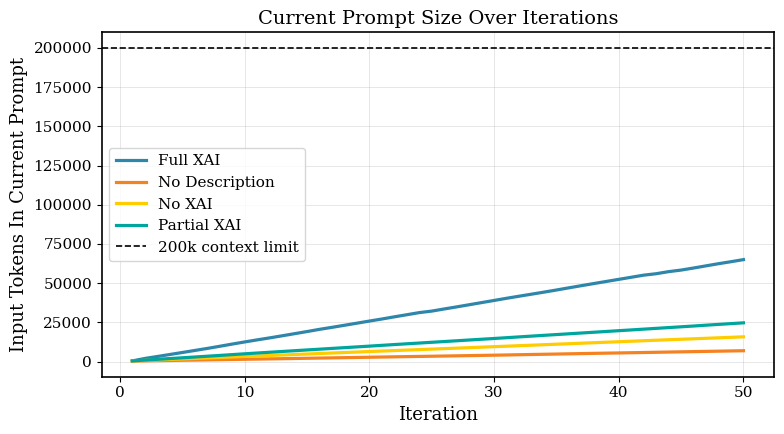

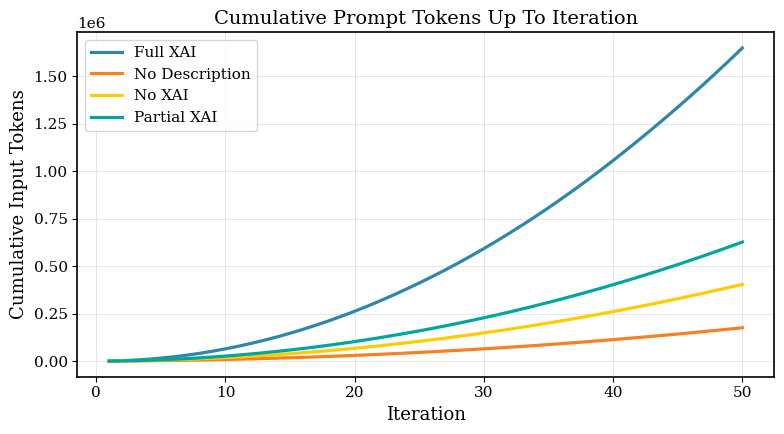

,mode,iteration,prompt_input_tokens_current,prompt_input_tokens_cumulative,context_utilization_pct_current,appended_feedback_token_estimate,prompt_growth_delta
0,Full XAI,1,403.000000,403.000000,0.201500,1424.333333,NaN
1,Full XAI,2,1958.333333,2361.333333,0.979167,1123.666667,1555.333333
2,Full XAI,3,3210.000000,5571.333333,1.605000,1129.666667,1251.666667
3,Full XAI,4,4486.333333,10057.666667,2.243167,1122.333333,1276.333333
4,Full XAI,5,5760.333333,15818.000000,2.880167,1130.000000,1274.000000
5,Full XAI,6,7052.000000,22870.000000,3.526000,1117.666667,1291.666667
6,Full XAI,7,8347.666667,31217.666667,4.173833,1188.000000,1295.666667
7,Full XAI,8,9721.333333,40939.000000,4.860667,1229.000000,1373.666667


In [18]:
iter_50 = all_iter_df[all_iter_df["iteration"] <= MAX_ITERATIONS_FOR_COST].copy()

agg_cols = [
    "prompt_input_tokens_current",
    "prompt_input_tokens_cumulative",
    "context_utilization_pct_current",
    "appended_feedback_token_estimate",
    "prompt_growth_delta",
]

iter_mean = (
    iter_50.groupby(["mode", "iteration"], as_index=False)[agg_cols]
    .mean(numeric_only=True)
)

# Plot 1: current prompt tokens by iteration
fig, ax = plt.subplots(figsize=(8, 4.5))
sns.lineplot(
    data=iter_mean,
    x="iteration",
    y="prompt_input_tokens_current",
    hue="mode",
    palette=MODE_COLORS,
    linewidth=2.3,
    ax=ax,
)
ax.axhline(CONTEXT_WINDOW_LIMIT, linestyle="--", color="black", linewidth=1.2, label="200k context limit")
ax.set_xlabel("Iteration")
ax.set_ylabel("Input Tokens In Current Prompt")
ax.set_title("Current Prompt Size Over Iterations")
ax.grid(alpha=0.35)
ax.legend(loc="best", frameon=True)
plt.tight_layout()
plt.savefig(FIG_DIR / "ic50mpro_qed_token_current_prompt.pdf", format="pdf", dpi=300, bbox_inches="tight")
plt.show()

# Plot 2: cumulative prompt tokens by iteration
fig, ax = plt.subplots(figsize=(8, 4.5))
sns.lineplot(
    data=iter_mean,
    x="iteration",
    y="prompt_input_tokens_cumulative",
    hue="mode",
    palette=MODE_COLORS,
    linewidth=2.3,
    ax=ax,
)
ax.set_xlabel("Iteration")
ax.set_ylabel("Cumulative Input Tokens")
ax.set_title("Cumulative Prompt Tokens Up To Iteration")
ax.grid(alpha=0.35)
ax.legend(loc="best", frameon=True)
plt.tight_layout()
plt.savefig(FIG_DIR / "ic50mpro_qed_token_cumulative_prompt.pdf", format="pdf", dpi=300, bbox_inches="tight")
plt.show()

iter_mean.head(8)

## Summary-Node Context Risk and Run Cost (Including Summary Call)

/var/folders/bx/x24x5dbd0hn0n2z56bs3rwq00000gn/T/ipykernel_13815/3942539977.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


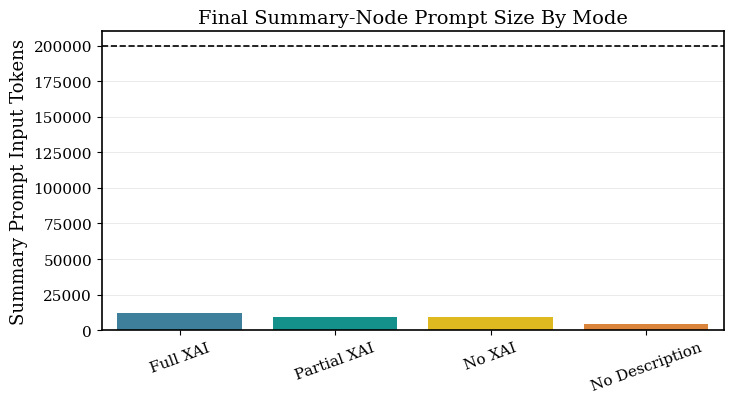

,mode,slope_tokens_per_iteration,projected_iteration_at_200k,summary_prompt_mean_tokens,summary_prompt_below_200k
0,Full XAI,1320.729604,151.973478,11733.000000,True
1,Partial XAI,493.571269,405.317098,9260.000000,True
2,No XAI,313.386699,637.889190,9075.666667,True
3,No Description,134.832413,1482.750442,4684.333333,True


In [19]:
summary_prompt_by_mode = (
    all_runs_df.groupby("mode", as_index=False)["summary_prompt_input_tokens"].mean()
    .sort_values("summary_prompt_input_tokens", ascending=False)
)

fig, ax = plt.subplots(figsize=(7.5, 4.2))
sns.barplot(
    data=summary_prompt_by_mode,
    x="mode",
    y="summary_prompt_input_tokens",
    palette=MODE_COLORS,
    ax=ax,
)
ax.axhline(CONTEXT_WINDOW_LIMIT, linestyle="--", color="black", linewidth=1.2)
ax.set_xlabel("")
ax.set_ylabel("Summary Prompt Input Tokens")
ax.set_title("Final Summary-Node Prompt Size By Mode")
ax.tick_params(axis="x", rotation=20)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(FIG_DIR / "ic50mpro_qed_token_summary_prompt.pdf", format="pdf", dpi=300, bbox_inches="tight")
plt.show()

# Iterations to hit 200k based on linear fit of mean current prompt size.
projection_rows = []
for mode in [m for m, _ in MODE_SPECS]:
    mode_df = iter_mean[iter_mean["mode"] == mode].sort_values("iteration")
    x = mode_df["iteration"].to_numpy(dtype=float)
    y = mode_df["prompt_input_tokens_current"].to_numpy(dtype=float)

    if len(x) >= 2:
        slope, intercept = np.polyfit(x, y, 1)
        if slope > 0:
            it_200k = (CONTEXT_WINDOW_LIMIT - intercept) / slope
        else:
            it_200k = np.inf
    else:
        slope, intercept, it_200k = np.nan, np.nan, np.nan

    summary_mean = float(
        all_runs_df.loc[all_runs_df["mode"] == mode, "summary_prompt_input_tokens"].mean()
    )

    projection_rows.append(
        {
            "mode": mode,
            "slope_tokens_per_iteration": slope,
            "projected_iteration_at_200k": it_200k,
            "summary_prompt_mean_tokens": summary_mean,
            "summary_prompt_below_200k": bool(summary_mean < CONTEXT_WINDOW_LIMIT),
        }
    )

projection_df = pd.DataFrame(projection_rows)
projection_df

In [20]:
# Mean appended/prompt growth stats (within real optimization prompts).
append_stats = (
    iter_50.groupby("mode", as_index=False)[
        ["appended_feedback_token_estimate", "prompt_growth_delta"]
    ]
    .mean(numeric_only=True)
    .rename(
        columns={
            "appended_feedback_token_estimate": "mean_appended_feedback_tokens_per_iteration",
            "prompt_growth_delta": "mean_total_prompt_growth_delta_per_iteration",
        }
    )
)

# Per-run 50-iteration optimization totals
opt_totals = (
    iter_50.groupby(["mode", "run_id", "replicate"], as_index=False)[
        ["prompt_input_tokens_current", "assistant_output_token_estimate"]
    ]
    .sum()
    .rename(
        columns={
            "prompt_input_tokens_current": "optimization_prompt_tokens_50",
            "assistant_output_token_estimate": "optimization_completion_tokens_50_est",
        }
    )
)

run_cost_df = opt_totals.merge(
    all_runs_df[
        [
            "mode",
            "run_id",
            "replicate",
            "summary_prompt_input_tokens",
            "summary_completion_token_estimate",
        ]
    ],
    on=["mode", "run_id", "replicate"],
    how="left",
)

run_cost_df["optimization_prompt_cost_usd"] = run_cost_df["optimization_prompt_tokens_50"] / 1_000_000 * PROMPT_PRICE_PER_M
run_cost_df["optimization_completion_cost_usd_est"] = run_cost_df["optimization_completion_tokens_50_est"] / 1_000_000 * COMPLETION_PRICE_PER_M
run_cost_df["optimization_total_cost_usd_est"] = (
    run_cost_df["optimization_prompt_cost_usd"]
    + run_cost_df["optimization_completion_cost_usd_est"]
)

run_cost_df["summary_prompt_cost_usd"] = run_cost_df["summary_prompt_input_tokens"] / 1_000_000 * PROMPT_PRICE_PER_M
run_cost_df["summary_completion_cost_usd_est"] = run_cost_df["summary_completion_token_estimate"] / 1_000_000 * COMPLETION_PRICE_PER_M
run_cost_df["summary_total_cost_usd_est"] = (
    run_cost_df["summary_prompt_cost_usd"]
    + run_cost_df["summary_completion_cost_usd_est"]
)

run_cost_df["run_total_cost_usd_est"] = (
    run_cost_df["optimization_total_cost_usd_est"] + run_cost_df["summary_total_cost_usd_est"]
)

cost_summary = (
    run_cost_df.groupby("mode", as_index=False)[
        [
            "optimization_prompt_tokens_50",
            "optimization_completion_tokens_50_est",
            "summary_prompt_input_tokens",
            "summary_completion_token_estimate",
            "optimization_prompt_cost_usd",
            "optimization_completion_cost_usd_est",
            "optimization_total_cost_usd_est",
            "summary_prompt_cost_usd",
            "summary_completion_cost_usd_est",
            "summary_total_cost_usd_est",
            "run_total_cost_usd_est",
        ]
    ]
    .mean(numeric_only=True)
)

final_table = cost_summary.merge(append_stats, on="mode", how="left")
final_table = final_table.merge(projection_df, on="mode", how="left")

pd.set_option("display.max_columns", None)
final_table.sort_values("mode")

,mode,optimization_prompt_tokens_50,optimization_completion_tokens_50_est,summary_prompt_input_tokens,summary_completion_token_estimate,optimization_prompt_cost_usd,optimization_completion_cost_usd_est,optimization_total_cost_usd_est,summary_prompt_cost_usd,summary_completion_cost_usd_est,summary_total_cost_usd_est,run_total_cost_usd_est,mean_appended_feedback_tokens_per_iteration,mean_total_prompt_growth_delta_per_iteration,slope_tokens_per_iteration,projected_iteration_at_200k,summary_prompt_mean_tokens,summary_prompt_below_200k
0,Full XAI,1.648137e+06,8316.000000,11733.000000,638.666667,8.240683,0.207900,8.448583,0.058665,0.015967,0.074632,8.523215,1148.486667,1318.557823,1320.729604,151.973478,11733.000000,True
1,No Description,1.757703e+05,3302.666667,4684.333333,590.333333,0.878852,0.082567,0.961418,0.023422,0.014758,0.038180,0.999598,64.880000,134.714286,134.832413,1482.750442,4684.333333,True
2,No XAI,4.042687e+05,5413.666667,9075.666667,610.000000,2.021343,0.135342,2.156685,0.045378,0.015250,0.060628,2.217313,201.086667,313.387755,313.386699,637.889190,9075.666667,True
3,Partial XAI,6.266597e+05,5599.000000,9260.000000,590.333333,3.133298,0.139975,3.273273,0.046300,0.014758,0.061058,3.334332,380.066667,495.537415,493.571269,405.317098,9260.000000,True


## Notes on Interpretation

- `prompt_input_tokens_current` is the token size of the full prompt actually sent to the model on that iteration.
- `prompt_input_tokens_cumulative` is the sum of those actual per-iteration prompt inputs up to that iteration.
- `appended_feedback_token_estimate` and `prompt_growth_delta` are decomposition aids for prompt growth; they do not replace full-prompt metrics.
- Completion-side values are estimates from saved assistant text because per-call output token metadata was not logged in generation-node outputs.
- Final run cost includes both optimization-loop calls and the final summary-node call.